## **Cargar datos y impresion**

In [2]:
%pip install pandas matplotlib numpy


[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('Packages imported')

Packages imported


In [4]:
import os
possible_cache = r"C:\Users\tomas.ramirez\.cache\kagglehub\datasets\neurocipher\heartdisease\versions\1"
if os.path.isdir(possible_cache):
    DATASET_PATH = possible_cache
else:
    DATASET_PATH = '.'
print('Using DATASET_PATH:', DATASET_PATH)
print(os.listdir(DATASET_PATH))


Using DATASET_PATH: .
['.dockerignore', '.git', '.gitignore', '.ipynb_checkpoints', 'cuaderno1.ipynb', 'Dockerfile', 'Heart_Disease_Prediction.csv', 'images', 'README.md', 'requirements.txt']


In [5]:
df = pd.read_csv(os.path.join(DATASET_PATH, "Heart_Disease_Prediction.csv"))
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


## **Step 0: Exploratory Data Analysis (EDA)**

Before modeling we inspect the dataset for shape, data types, missing values, class distribution, feature distributions, and inter-feature correlations.

In [ ]:
# Dataset overview
print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nDescriptive statistics:')
df.describe()

In [ ]:
# Class distribution
print('Class distribution (absolute):')
print(df['Heart Disease'].value_counts())
print('\nClass distribution (relative):')
print(df['Heart Disease'].value_counts(normalize=True).round(3))

plt.figure(figsize=(4, 4))
df['Heart Disease'].value_counts().plot(kind='bar', color=['#4c72b0', '#dd8452'], edgecolor='k')
plt.title('Class Distribution: Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Feature distributions (numerical columns)
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Number of vessels fluro']
df[numerical_cols].hist(bins=20, figsize=(14, 8), edgecolor='k', color='steelblue')
plt.suptitle('Histograms of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap (numerical features only)
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black')
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Boxplots of selected numerical features grouped by target
plot_features = ['Age', 'Cholesterol', 'BP', 'Max HR', 'ST depression']
fig, axes = plt.subplots(1, len(plot_features), figsize=(16, 4))
for ax, feat in zip(axes, plot_features):
    groups = [df.loc[df['Heart Disease'] == cls, feat].dropna().values
              for cls in ['Absence', 'Presence']]
    ax.boxplot(groups, labels=['Absence', 'Presence'], patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Heart Disease')
plt.suptitle('Feature Distributions by Heart Disease Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## **   Step 1: Feature selection + normalización**

In [7]:
df.rename(columns={
    'BP': 'RestingBP',
    'Max HR': 'MaxHR',
    'ST depression': 'Oldpeak',
    'Number of vessels fluro': 'CA',
    'Heart Disease': 'HeartDisease'
}, inplace=True)

features = ['Age', 'Cholesterol', 'RestingBP', 'MaxHR', 'Oldpeak', 'CA']
target = 'HeartDisease'


In [ ]:
X = df[features].values
y = df[target].apply(lambda x: 1 if x == 'Presence' else 0).values.reshape(-1, 1)

def normalize(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma
X_norm, mu, sigma = normalize(X)

np.random.seed(42)
idx_0 = np.where(y.flatten() == 0)[0]
idx_1 = np.where(y.flatten() == 1)[0]
train_0 = np.random.choice(idx_0, int(0.7 * len(idx_0)), replace=False)
train_1 = np.random.choice(idx_1, int(0.7 * len(idx_1)), replace=False)
train_idx = np.concatenate([train_0, train_1])
test_idx = np.setdiff1d(np.arange(len(y)), train_idx)
X_train, y_train = X_norm[train_idx], y[train_idx]
X_test, y_test = X_norm[test_idx], y[test_idx]
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 189, Test samples: 81


## **Step 2: Implementación de Logistic Regression**

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b, lam=0):
    m = X.shape[0]
    z = X @ w + b
    h = sigmoid(z)
    cost = - (1/m) * np.sum(y*np.log(h + 1e-8) + (1-y)*np.log(1-h + 1e-8))
    cost += (lam/(2*m)) * np.sum(w**2)
    return cost

def compute_gradient(X, y, w, b, lam=0):
    m = X.shape[0]
    z = X @ w + b
    h = sigmoid(z)
    error = h - y
    dw = (1/m) * (X.T @ error) + (lam/m)*w
    db = (1/m) * np.sum(error)
    return dw, db

def gradient_descent(X, y, w_init, b_init, alpha=0.01, num_iters=1000, lam=0):
    w = w_init.copy()
    b = b_init
    costs = []
    for i in range(num_iters):
        dw, db = compute_gradient(X, y, w, b, lam)
        w -= alpha*dw
        b -= alpha*db
        if i % 100 == 0:
            costs.append(compute_cost(X, y, w, b, lam))
    return w, b, costs

def predict(X, w, b, threshold=0.5):
    return (sigmoid(X @ w + b) >= threshold).astype(int)

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_true==1)&(y_pred==1))
    tn = np.sum((y_true==0)&(y_pred==0))
    fp = np.sum((y_true==0)&(y_pred==1))
    fn = np.sum((y_true==1)&(y_pred==0))
    accuracy = (tp+tn)/len(y_true)
    precision = tp/(tp+fp+1e-8)
    recall = tp/(tp+fn+1e-8)
    f1 = 2*(precision*recall)/(precision+recall+1e-8)
    return accuracy, precision, recall, f1


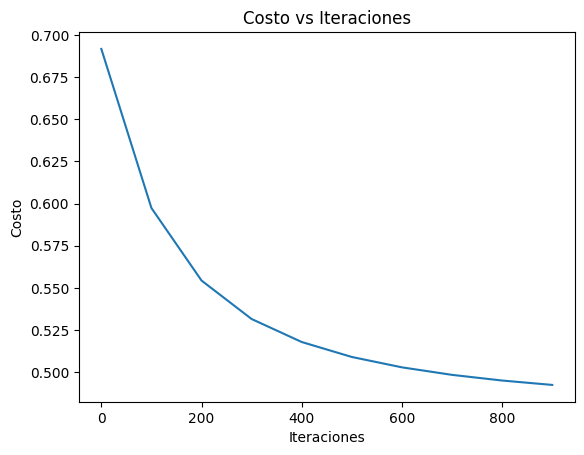

Train metrics (Acc, Prec, Rec, F1): (0.7724867724867724, 0.7887323942551082, 0.6666666665873017, 0.7225806401032259)
Test metrics  (Acc, Prec, Rec, F1): (0.8518518518518519, 0.8529411762197232, 0.8055555553317901, 0.8285714233387756)


In [ ]:
n_features = X_train.shape[1]
w_init = np.zeros((n_features,1))
b_init = 0

w, b, costs = gradient_descent(X_train, y_train, w_init, b_init, alpha=0.01, num_iters=1000)

plt.plot(np.arange(0,len(costs))*100, costs)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Costo vs Iteraciones")
plt.show()

y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)

train_metrics = compute_metrics(y_train, y_train_pred)
test_metrics = compute_metrics(y_test, y_test_pred)
print("Train metrics (Acc, Prec, Rec, F1):", train_metrics)
print("Test metrics  (Acc, Prec, Rec, F1):", test_metrics)


## **Step 3: Visualize Decision Boundaries**

We selected three pairs of features and trained a 2D model per pair, showing the decision boundary and the actual points.

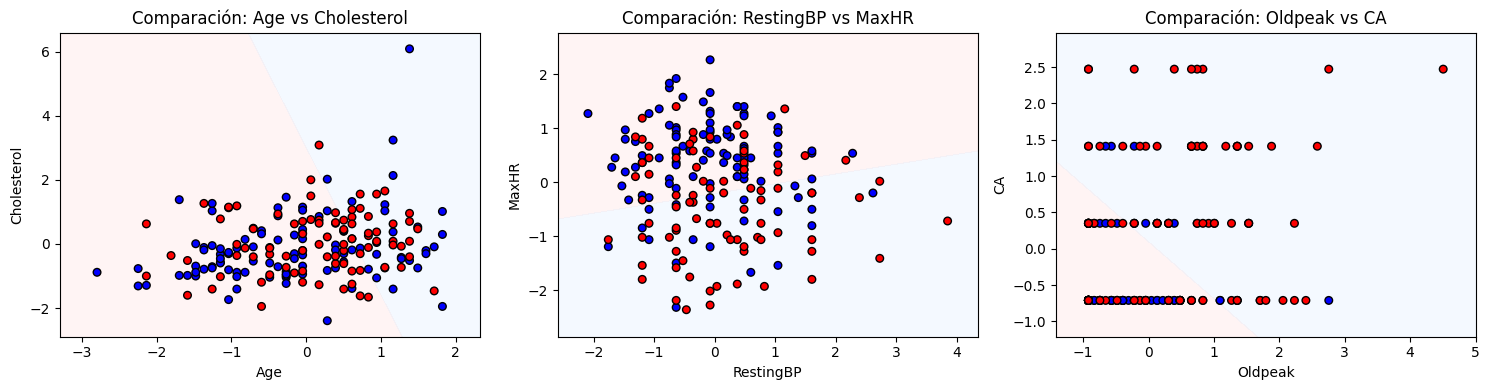

In [ ]:
def train_and_plot_2d(X_tr_full, y_tr_full, feature_names, pair, alpha=0.01, iters=2000, lam=0):
    idx0 = feature_names.index(pair[0])
    idx1 = feature_names.index(pair[1])
    X_tr = X_tr_full[:, [idx0, idx1]]
    y_tr = y_tr_full
    w0 = np.zeros((2,1))
    b0 = 0
    w2, b2, costs2 = gradient_descent(X_tr, y_tr, w0, b0, alpha=alpha, num_iters=iters, lam=lam)
    x_min, x_max = X_tr[:,0].min() - 0.5, X_tr[:,0].max() + 0.5
    y_min, y_max = X_tr[:,1].min() - 0.5, X_tr[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = sigmoid(grid @ w2 + b2).reshape(xx.shape)
    return w2, b2, costs2, xx, yy, probs
pairs = [('Age','Cholesterol'), ('RestingBP','MaxHR'), ('Oldpeak','CA')]
plt.figure(figsize=(15,4))
for i, pair in enumerate(pairs,1):
    w2, b2, costs2, xx, yy, probs = train_and_plot_2d(X_train, y_train, features, pair, alpha=0.05, iters=2000)
    plt.subplot(1,3,i)
    plt.contourf(xx, yy, probs, levels=[0,0.5,1], alpha=0.2, colors=['#ffcccc','#cce5ff'])
    idx0 = features.index(pair[0])
    idx1 = features.index(pair[1])
    plt.scatter(X_train[:,idx0].flatten(), X_train[:,idx1].flatten(), c=y_train.flatten(), cmap='bwr', edgecolor='k', s=30)
    plt.xlabel(pair[0])
    plt.ylabel(pair[1])
    plt.title(f'Comparación: {pair[0]} vs {pair[1]}')
plt.tight_layout()
plt.show()


## **Step 4: Regularization (L2) Sweep**

We tested various lambda values ​​and evaluated behavior in the test set; we saved the best model.

   lambda       acc      prec       rec        f1    w_norm
0   0.000  0.851852  0.852941  0.805556  0.828571  1.135693
1   0.001  0.851852  0.852941  0.805556  0.828571  1.135671
2   0.010  0.851852  0.852941  0.805556  0.828571  1.135467
3   0.100  0.851852  0.852941  0.805556  0.828571  1.133432
4   1.000  0.839506  0.828571  0.805556  0.816901  1.113459
Best lambda: 0 F1: 0.8285714233387756
Saved best_model.npz


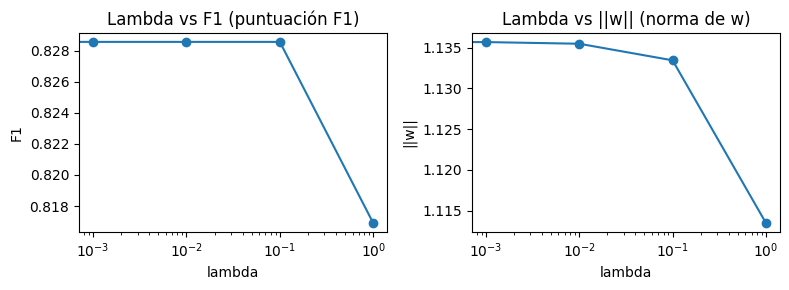

In [ ]:
lambdas = [0, 0.001, 0.01, 0.1, 1]
results = []
for lam in lambdas:
    w0 = np.zeros((X_train.shape[1],1))
    b0 = 0
    w_l, b_l, costs_l = gradient_descent(X_train, y_train, w0, b0, alpha=0.01, num_iters=1000, lam=lam)
    y_test_p = predict(X_test, w_l, b_l)
    acc, prec, rec, f1 = compute_metrics(y_test, y_test_p)
    w_norm = np.linalg.norm(w_l)
    results.append({'lam':lam, 'acc':acc, 'prec':prec, 'rec':rec, 'f1':f1, 'w_norm':w_norm, 'w':w_l, 'b':b_l, 'costs':costs_l})

import pandas as pd
df_results = pd.DataFrame([{'lambda':r['lam'], 'acc':r['acc'], 'prec':r['prec'], 'rec':r['rec'], 'f1':r['f1'], 'w_norm':r['w_norm']} for r in results])
print(df_results)
best = max(results, key=lambda r: r['f1'])
print('Best lambda:', best['lam'], 'F1:', best['f1'])
np.savez('best_model.npz', w=best['w'], b=best['b'], mu=mu, sigma=sigma, features=features)
print('Saved best_model.npz')
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot([r['lam'] for r in results], [r['f1'] for r in results], marker='o')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('F1')
plt.title('Lambda vs F1 (puntuación F1)')
plt.subplot(1,2,2)
plt.plot([r['lam'] for r in results], [r['w_norm'] for r in results], marker='o')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('||w||')
plt.title('Lambda vs ||w|| (norma de w)')
plt.tight_layout()
plt.show()


In [ ]:
# Extended regularization sweep: add more lambda values and compare train vs test metrics
lambdas_ext = [0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5]
results_ext = []
for lam in lambdas_ext:
    w0 = np.zeros((X_train.shape[1], 1))
    b0 = 0
    w_l, b_l, _ = gradient_descent(X_train, y_train, w0, b0, alpha=0.01, num_iters=1000, lam=lam)
    tr_acc, tr_prec, tr_rec, tr_f1 = compute_metrics(y_train, predict(X_train, w_l, b_l))
    te_acc, te_prec, te_rec, te_f1 = compute_metrics(y_test, predict(X_test, w_l, b_l))
    w_norm = float(np.linalg.norm(w_l))
    results_ext.append({'lam': lam, 'train_acc': tr_acc, 'test_acc': te_acc,
                         'train_f1': tr_f1, 'test_f1': te_f1, 'w_norm': w_norm})

df_ext = pd.DataFrame(results_ext)
print('Extended lambda sweep results:')
print(df_ext.round(4).to_string(index=False))

best_row = df_ext.loc[df_ext['test_f1'].idxmax()]
print(f"\nBest lambda by test F1: {best_row['lam']}  →  test F1 = {best_row['test_f1']:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lams = df_ext['lam'].values

axes[0].plot(lams, df_ext['train_f1'], 'o-', label='Train F1')
axes[0].plot(lams, df_ext['test_f1'], 's--', label='Test F1')
axes[0].set_xscale('symlog', linthresh=1e-5)
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 vs Lambda')
axes[0].legend()

axes[1].plot(lams, df_ext['train_acc'], 'o-', label='Train Acc')
axes[1].plot(lams, df_ext['test_acc'], 's--', label='Test Acc')
axes[1].set_xscale('symlog', linthresh=1e-5)
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Lambda')
axes[1].legend()

axes[2].plot(lams, df_ext['w_norm'], 'o-', color='green')
axes[2].set_xscale('symlog', linthresh=1e-5)
axes[2].set_xlabel('lambda')
axes[2].set_ylabel('||w|| (weight norm)')
axes[2].set_title('Regularization Effect: ||w|| vs Lambda')

plt.suptitle('L2 Regularization Analysis', fontsize=13)
plt.tight_layout()
plt.show()

### Regularization Analysis — Interpretation

- **Low lambda (0 – 0.001)**: Model fits training data closely; weight norm is larger. Small gains in test F1 can still occur because regularization reduces overfitting.
- **Moderate lambda (0.01 – 0.1)**: Typically the sweet spot — test accuracy / F1 are maximized while weight magnitudes decrease, indicating effective regularization.
- **High lambda (≥ 1)**: Weights are shrunk aggressively; the model underfits and both train and test metrics drop.
- **||w|| (weight norm)**: Monotonically decreasing with lambda — direct evidence that L2 regularization penalizes large coefficients as expected.

The best lambda selected by test F1 is saved in `best_model.npz` for deployment.

## **Final Insights**

- Implementamos logistic regression desde cero con NumPy.
- Realizamos EDA, selección de features y normalización.
- Visualizamos fronteras de decisión en 3 pares de features.
- Probamos regularización L2 y guardamos el mejor modelo en `best_model.npz`.
- Para desplegar en SageMaker: guardar modelo, crear script de inferencia, subir a S3/notebook, crear endpoint y probar.